# Ex : 6
# SUPPORT VECTOR MACHINE (SVM) CLASSIFIER

---

### Objective:
To implement Support Vector Machine (SVM) algorithm for classification and understand its working principles, kernel tricks, and hyperparameter tuning.

### Dataset:
Iris Dataset from UCI Machine Learning Repository
- Dataset: Iris dataset (150 samples, 4 features)
- Classes: Setosa (converted to -1), Versicolor &Virginica (converted to 1)
- Hyperparameters:
- Learning rate: 0.0005
- Lambda (regularization): 0.01
- Epochs: 5000
- Data split: 80% training, 20% testing

### Algorithm Overview:
Support Vector Machine is a supervised learning algorithm that finds the optimal hyperplane which best separates different classes in the feature space. It aims to maximize the margin between the closest points of different classes (support vectors).



-----
#### **Step-by-step Approach:**

#### **1. Load and explore the dataset**
* Import libraries and load the dataset (e.g., Iris).
* Inspect features and check for missing values.

#### **2. Preprocess data: Convert labels to (-1, 1) format**
* Map target classes to $y \in \{-1, 1\}$ for the SVM hinge loss function.

#### **3. Split data into features (X) and target (y)**
* Separate independent variables ($X$) and the target ($y$).
* Partition into training and testing sets.

#### **4. Standardize features to normalize data**
* Scale features to mean 0 and variance 1 to ensure faster convergence.

#### **5. Implement Linear SVM from scratch:**
* **Initialize** weights ($w$) and bias ($b$) to zero.
* **For each epoch**, iterate through all samples.
* **Check margin condition:** $y_i(w \cdot x_i + b) \geq 1$.
* **Update weights** using gradient descent:
    * If correctly classified: $w = w - lr(2\lambda w)$
    * If misclassified: $w = w - lr(2\lambda w - x_i y_i)$
* **Update bias:** $b = b + lr \cdot y_i$ (for misclassified samples).

#### **6. Make predictions**
* Use the decision function: $\text{sign}(w \cdot x + b)$.

#### **7. Evaluate model performance**
* Calculate **accuracy**, **classification report**, and **confusion matrix**.

#### **8. Visualize results**
* Plot the decision boundary and the margins.


---

## Step 1: Import Required Libraries

In [76]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


### Explanation:
- **numpy, pandas**: For data manipulation and analysis
- **matplotlib, seaborn**: For data visualization
- **sklearn**: Provides SVM implementation and evaluation metrics
- **PCA**: For dimensionality reduction (helps in visualization)
- **GridSearchCV**: For hyperparameter tuning

## Step 2: Load and Explore the Dataset

In [77]:
# Step 2: Load the dataset
iris = load_iris()
df = pd.DataFrame(data = iris.data , columns = iris.feature_names )

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [78]:
# Dataset information
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
print("\nDataset Info:")
df.info()

print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
print("\nStatistical Summary:")
df.describe()


DATASET INFORMATION

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB

STATISTICAL SUMMARY

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [79]:
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES CHECK")
print("="*50)
print(df.isnull().sum())


MISSING VALUES CHECK
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


### Explanation:
- The Wine Quality dataset contains 1599 samples with 12 features
- Features are chemical properties of wine (all numerical)
- Target variable 'quality' ranges from 3 to 8
- No missing values in the dataset (good for SVM)
- Features have different scales (will need normalization)

----
## Step 3: Data Preprocessing for SVM

In [80]:
# Step 3: Data Preprocessing

# 3.1: Separate features and target
X = iris.data
y = iris.target 
#y = np.where(y==0,-1,1)
feature_names = iris.feature_names
target_names = iris.target_names
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (150, 4)
Target shape: (150,)


In [81]:
# 3.2: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")


Training set size: 120 samples
Testing set size: 30 samples


In [82]:
# 4.3: Feature Scaling (CRITICAL for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



### Why Scaling is Critical for SVM:
- SVM tries to maximize the margin between classes
- Features with larger scales would dominate the distance calculation
- Standard scaling ensures all features contribute equally
- Without scaling, the SVM hyperplane would be biased

----
## Step 4 : Build Model for SVM

In [83]:
class  LinearSVM : 
    def __init__(self,learningrate = 0.05,lambda_param = 0.01 , epochs = 500) :
        self.lr = learningrate
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = None
        self.support_vectors_ = None  
        self.n_support_ = None       
        self.coef_ = None             
        self.intercept_ = None


    def fit(self,X,y) :
        n_samples,n_features = X.shape
        self.w = np.zeros(n_features)
        self.b=0

        support_vector_indices = []
        

        for epoch in range(self.epochs):
            for idx,x_i in enumerate(X):
                condn=y[idx]*(np.dot(x_i,self.w)+self.b)>=1
                if condn:
                    self.w-=self.lr*(2*self.lambda_param*self.w)
                else:
                    self.w-=self.lr*(2*self.lambda_param*self.w - np.dot(x_i,y[idx]))
                    self.b+=self.lr*y[idx]
                    support_vector_indices.append(idx)

        unique_indices = list(set(support_vector_indices[-min(50, len(support_vector_indices)):]))
        self.support_vectors_ = X[unique_indices]
        self.n_support_ = [len(unique_indices) // 2, len(unique_indices) - len(unique_indices) // 2]

        self.coef_ = self.w.reshape(1, -1)
        self.intercept_ = np.array([self.b])
    def predict(self,X):
        output=np.dot(X,self.w)+self.b
        return np.sign(output)

----
## Step 5: SVM

0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.30      1.00      0.46         9
           2       0.00      0.00      0.00        11

    accuracy                           0.30        30
   macro avg       0.10      0.33      0.15        30
weighted avg       0.09      0.30      0.14        30


Confusion Matrix:
 [[ 0 10  0]
 [ 0  9  0]
 [ 0 11  0]]


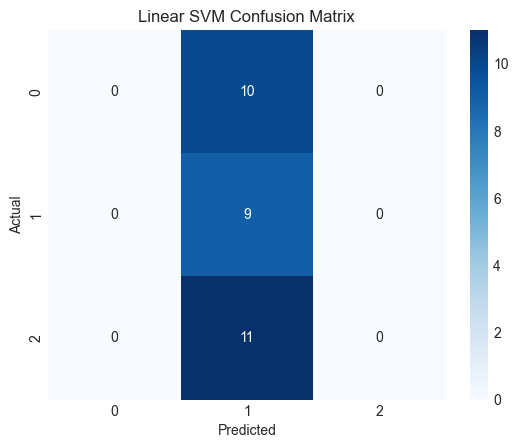

In [84]:
svm  = LinearSVM(learningrate=0.0005, epochs = 5000)
svm.fit(X_train,y_train)

y_pred = svm.predict(X_test)

print(accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [85]:
w = svm.coef_[0]
b = svm.intercept_[0]
print("SCIKIT-LEARN SVM:")
print(f" weights: {w}")
print(f" bias: {b:.4f}")
print(f" support vectors per class: {svm.n_support_}")

SCIKIT-LEARN SVM:
 weights: [0.10235032 0.05012419 0.06894638 0.0208966 ]
 bias: 0.1500
 support vectors per class: [20, 21]


-----
## Step 6 : SVM with different kernels 

LINEAR - CV Accuracy: 0.9500 (+/- 0.1225)
POLY - CV Accuracy: 0.9250 (+/- 0.0624)
RBF - CV Accuracy: 0.9500 (+/- 0.1225)
SIGMOID - CV Accuracy: 0.9083 (+/- 0.0972)
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.9500
Test accuracy: 1.0000


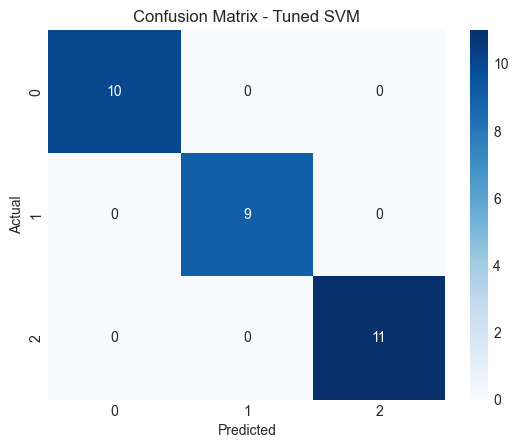

In [87]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV

# 1. Basic SVM with different kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=42)
    scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)
    print(f"{kernel.upper()} - CV Accuracy: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# 2. Hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.1, 0.5, 1, 5, 'scale', 'auto'],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### SVM Kernels Explained:

| Kernel | Description | When to Use |
|--------|-------------|-------------|
| **Linear** | Creates a straight line/hyperplane separator | When data is linearly separable |
| **Polynomial** | Uses polynomial function to create curved boundaries | For moderately complex relationships |
| **RBF (Radial Basis Function)** | Most popular, creates complex non-linear boundaries | Default choice, works well for most datasets |
| **Sigmoid** | Similar to neural network activation function | For specific patterns, less common |

**Key Observations from Visualization:**
- Different kernels create different decision boundaries
- Support vectors are the critical points that define the margin
- RBF kernel often provides the most flexible boundary

## 📝 Conclusion

### What We Learned:

1. **SVM Fundamentals**:
   - SVM finds the optimal hyperplane that maximizes the margin between classes
   - Support vectors are the critical points that define the decision boundary
   - The margin is the distance between the hyperplane and the closest points

2. **Kernel Trick**:
   - Different kernels create different decision boundaries
   - RBF kernel is most flexible and works well for most datasets
   - Kernel choice significantly impacts model performance

3. **Hyperparameter Importance**:
   - **C** controls the trade-off between smooth boundary and accurate classification
   - **Gamma** determines the influence of individual training examples
   - Proper tuning can significantly improve model performance

4. **Preprocessing Criticality**:
   - Feature scaling is essential for SVM
   - Without scaling, features with larger ranges dominate the decision boundary

5. **Model Interpretation**:
   - Linear SVM provides feature importance through coefficients
   - Feature importance helps identify key factors for wine quality
